# Causal Analysis for Trading Decisions: A Momentum Case Study

**Chapter 15: Causal Estimation with ML**
**Docker image**: `ml4t`

Causal inference applied to a trading decision, and what it does and does not settle once
the strategy meets a holdout period.

**Section Reference**: Section 15.4, and its regime-conditional position-sizing case study

**The Question**: Does momentum have a causal effect on forward returns, and
does this effect vary by volatility regime?

**Methodological Approach**:
1. Define a clear train/test split (no look-ahead bias)
2. Estimate causal effects using only training data
3. Apply regime-conditional allocation to held-out test period
4. Compare to naive baseline and simple alternatives
5. Include transaction costs

What the notebook shows is the workflow, and what the workflow produces on this data is a
case where the in-sample improvement does not carry to the holdout. That is the usual
outcome and it is the reason the split exists.

**Learning Outcomes**:
- Estimate causal effects on training data alone and apply them to a holdout period
- Separate what a causal estimate establishes from what it earns in a backtest
- Turn a regime-conditional effect into a position size, and compare it against a
  baseline that uses no causal machinery at all

**Prerequisites**: [`03_econml_dml`](03_econml_dml.ipynb) for the DML machinery, and an
ETF modeling dataset built by the features pipeline

## Causal Design Contract

| Element                   | This notebook                                                                                |
|---------------------------|----------------------------------------------------------------------------------------------|
| Unit                      | ETF-date row from the ETF modeling panel                                                     |
| Treatment                 | `skip_recent_6_1` momentum (continuous)                                                       |
| Outcome                   | `fwd_ret_21d` - 21-day forward return                                                         |
| Controls (W)              | `vol_21d`, `vol_63d`, `vol_126d`, `yield_curve_slope`                                         |
| Effect modifiers (X)      | `market_volatility` (SPY 63-day vol) + high-/low-vol regime indicators, via CausalForestDML   |
| Identification assumption | Selection on observables given the four controls; CATE varies smoothly with realized vol     |
| Main failure modes        | Unobserved confounding; CATE generalization failure out of sample; trading cost erosion       |
| Estimand                  | ATE and regime-conditional CATE from CausalForestDML; downstream trading rule scales position by sign-of-CATE × magnitude |

## 1. Setup and Configuration

In [1]:
"""Causal Analysis for Trading Decisions - apply DML-based causal estimates to a momentum trading strategy."""

import datetime
import json
import warnings

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots
from scipy import stats
from sklearn.ensemble import GradientBoostingRegressor

import utils.style  # noqa: F401  # registers + activates the ml4t Plotly template
from utils.cv_splits import most_recent_split
from utils.modeling import load_modeling_dataset
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_plotly_with_alt

# scikit-learn repeats a notice, once per nuisance fit, that a frame carrying feature names
# was fitted and a bare array predicted; EconML does that internally. Convergence and
# numerical warnings stay visible.
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.validation")

# Try to import EconML
try:
    from econml.dml import CausalForestDML, LinearDML

    ECONML_AVAILABLE = True
    print("EconML available")
except Exception as e:
    print(f"EconML unavailable ({type(e).__name__}: {e})")
    print("Install/fix with: uv pip install econml")
    ECONML_AVAILABLE = False

EconML available


In [2]:
# Configuration
CASE_STUDY_ID = "etfs"
PRIMARY_LABEL = "fwd_ret_21d"
MAX_SYMBOLS = 0
SEED = 42
RETRAIN = True  # Refit from raw; set False to reuse a cache you built earlier
MAX_SAMPLES = 0

# Momentum parameters
FORWARD_DAYS = 21  # Forward return horizon (matches label)

# Strategy parameters
N_QUANTILES = 5  # Quintile portfolios
# A date needs at least this many complete pairs before its cross-sectional rank
# correlation is worth averaging into the IC; a five-name cross-section is noise.
MIN_IC_NAMES = 20

# Transaction Costs: 10 bps round-trip for liquid ETFs
TRANSACTION_COST_BPS = 10

# DML parameters
CV_FOLDS = 5
RUN_TAG = "full"  # Suffix for cached artifacts
SYMBOL_SUBSET = []
DML_NUISANCE_ESTIMATORS = 100
CF_MODEL_ESTIMATORS = 100
CF_FOREST_ESTIMATORS = 500

In [3]:
set_global_seeds(SEED)

CACHE_TAG = RUN_TAG
OUTPUT_DIR = get_output_dir(15, "momentum_causal_trading")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DML_CACHE_PATH = OUTPUT_DIR / f"dml_artifacts_{CASE_STUDY_ID}_{PRIMARY_LABEL}_{CACHE_TAG}.json"

print("Momentum Causal Trading Configuration:")
print(f"  Forward: {FORWARD_DAYS} days")
print(f"  Transaction cost: {TRANSACTION_COST_BPS} bps")
print(f"  Run tag: {RUN_TAG}")
print(f"  Retrain DML artifacts: {RETRAIN}")

Momentum Causal Trading Configuration:
  Forward: 21 days
  Transaction cost: 10 bps
  Run tag: full
  Retrain DML artifacts: True


## 2. Load ETF Features from Modeling Pipeline

We use `load_modeling_dataset()` to load pre-computed momentum features (Ch8),
temporal features (Ch9), and labels from the case study pipeline.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)
splits = mds.splits

# Key columns
treatment_col = "skip_recent_6_1"  # 6-month skip-recent momentum
outcome_col = mds.label_col
date_col = mds.date_col

# We need momentum, volatility, and regime for the trading strategy
needed_cols = [
    date_col,
    "symbol",
    treatment_col,
    outcome_col,
    "vol_63d",
    "regime",
    "yield_curve_slope",
    "vol_21d",
    "vol_126d",
]

available = set(mds.dataset.columns)
analysis_cols = [c for c in needed_cols if c in available]

# Convert to pandas for downstream analysis
features_df = mds.dataset.select(analysis_cols).drop_nulls().sort(date_col)
print(
    f"Feature dataset: {features_df.shape[0]:,} observations across {features_df['symbol'].n_unique()} ETFs"
)
print(f"Date range: {features_df[date_col].min()} to {features_df[date_col].max()}")

# Optional asset subset for faster runs
if SYMBOL_SUBSET:
    features_df = features_df.filter(pl.col("symbol").is_in(SYMBOL_SUBSET))
    print(f"Reduced to {features_df['symbol'].n_unique()} assets")

Feature dataset: 402,526 observations across 99 ETFs
Date range: 2007-01-03 to 2025-12-01


### Defining the Market Volatility Regime

We define regime based on market-wide volatility (SPY as proxy).
This is a potential confounder OR effect modifier.

In [5]:
def assign_volatility_regime(features_df, date_col, splits):
    """Assign market volatility regime labels using pre-holdout thresholds."""
    if "regime" in features_df.columns:
        # Regime already computed in Ch8 features
        # Map numeric regime to string labels for strategy logic
        # Use SPY when available; otherwise fall back to cross-sectional median volatility.
        if features_df.filter(pl.col("symbol") == "SPY").height > 0:
            market_vol = (
                features_df.filter(pl.col("symbol") == "SPY")
                .select([date_col, "vol_63d"])
                .rename({"vol_63d": "market_volatility"})
            )
            market_vol_source = "SPY"
        else:
            market_vol = (
                features_df.group_by(date_col)
                .agg(pl.col("vol_63d").median().alias("market_volatility"))
                .sort(date_col)
            )
            market_vol_source = "cross-sectional median"

        # The boundary is the latest fold's validation start, read from the window
        # rather than from a list position.
        holdout_boundary = datetime.date.fromisoformat(
            str(most_recent_split(splits)["val_start"])[:10]
        )

        # Regime thresholds from pre-holdout data only
        train_market_vol = market_vol.filter(pl.col(date_col) < holdout_boundary)
        vol_values = train_market_vol["market_volatility"].drop_nulls().to_numpy()
        if len(vol_values) == 0:
            vol_values = (
                features_df.filter(pl.col(date_col) < holdout_boundary)["vol_63d"]
                .drop_nulls()
                .to_numpy()
            )
            market_vol_source = f"{market_vol_source} fallback"

        low_thresh = np.percentile(vol_values, 33)
        high_thresh = np.percentile(vol_values, 67)

        print(f"Regime thresholds (source={market_vol_source}):")
        print(f"  Low volatility: < {low_thresh:.2%}")
        print(f"  High volatility: > {high_thresh:.2%}")

        market_vol = market_vol.with_columns(
            pl.when(pl.col("market_volatility") < low_thresh)
            .then(pl.lit("low_vol"))
            .when(pl.col("market_volatility") > high_thresh)
            .then(pl.lit("high_vol"))
            .otherwise(pl.lit("mid_vol"))
            .alias("regime_label")
        )

        features_df = features_df.join(
            market_vol.select([date_col, "market_volatility", "regime_label"]),
            on=date_col,
            how="inner",
        )
    else:
        # Fallback: compute from vol_63d
        features_df = features_df.with_columns(
            pl.lit("mid_vol").alias("regime_label"),
            pl.col("vol_63d").alias("market_volatility"),
        )
    return features_df


features_df = assign_volatility_regime(features_df, date_col, splits)

Regime thresholds (source=SPY):
  Low volatility: < 11.85%
  High volatility: > 17.73%


### The Train/Test Split

We use the walk-forward splits from the modeling pipeline.
Training: all folds except last validation period.
Test: last validation period (most recent data).

In [6]:
# The latest fold, read from the window rather than from a list position.
_latest_split = most_recent_split(splits)
TRAIN_END = _latest_split["train_end"]
TEST_START = _latest_split["val_start"]

_train_end = datetime.date.fromisoformat(str(TRAIN_END)[:10])
_test_start = datetime.date.fromisoformat(str(TEST_START)[:10])
train_df = features_df.filter(pl.col(date_col) <= _train_end)
test_df = features_df.filter(pl.col(date_col) >= _test_start)

if MAX_SAMPLES and train_df.height > MAX_SAMPLES:
    print(f"Taking most recent {MAX_SAMPLES:,} training rows from {train_df.height:,}")
    train_df = train_df.tail(MAX_SAMPLES)

assert _train_end < _test_start, f"Train end {_train_end} must precede test start {_test_start}"
assert train_df[date_col].max() < test_df[date_col].min(), (
    "Train and test date ranges overlap - split logic is broken"
)

print(f"\nTrain set: {len(train_df):,} observations")
print(f"Test set:  {len(test_df):,} observations")
print(f"Train end: {TRAIN_END}")
print(f"Test start: {TEST_START}")

print("\nRegime distribution (TRAIN):")
print(train_df.group_by("regime_label").agg(pl.len().alias("count")))

print("\nRegime distribution (HOLDOUT):")
print(test_df.group_by("regime_label").agg(pl.len().alias("count")))


Train set: 331,379 observations
Test set:  69,152 observations
Train end: 2022-11-28 00:00:00
Test start: 2022-12-29 00:00:00

Regime distribution (TRAIN):
shape: (3, 2)
┌──────────────┬────────┐
│ regime_label ┆ count  │
│ ---          ┆ ---    │
│ str          ┆ u32    │
╞══════════════╪════════╡
│ low_vol      ┆ 115168 │
│ high_vol     ┆ 103625 │
│ mid_vol      ┆ 112586 │
└──────────────┴────────┘

Regime distribution (HOLDOUT):
shape: (3, 2)
┌──────────────┬───────┐
│ regime_label ┆ count │
│ ---          ┆ ---   │
│ str          ┆ u32   │
╞══════════════╪═══════╡
│ mid_vol      ┆ 31737 │
│ low_vol      ┆ 27377 │
│ high_vol     ┆ 10038 │
└──────────────┴───────┘


## 3. Training Period: Estimate Causal Effects

We fit all causal models on the TRAINING data only. These estimates will
then be applied to the held-out test period.

In [7]:
print("\n" + "=" * 60)
print("TRAINING PERIOD ANALYSIS")
print("=" * 60)

train_pd = train_df.to_pandas()


def cross_sectional_ic(frame: pd.DataFrame) -> float:
    """Mean over dates of the cross-sectional Spearman correlation.

    The strategy sorts each date's cross-section into quintiles, so the association it
    trades is a within-date one. Pooling every symbol-date row into a single Spearman
    mixes that with the market's own time series, and the two need not even share a sign.
    Ranks are taken within a date, and dates with fewer than `MIN_IC_NAMES` complete pairs
    contribute nothing.
    """
    pairs = frame[[date_col, treatment_col, outcome_col]].dropna()
    per_date = pairs.groupby(date_col).apply(
        lambda g: (
            stats.spearmanr(g[treatment_col], g[outcome_col])[0]
            if len(g) >= MIN_IC_NAMES
            else np.nan
        ),
        include_groups=False,
    )
    return float(per_date.mean())


train_ic = cross_sectional_ic(train_pd)
print(f"\nMomentum IC (train): {train_ic:.4f}")

print("\nIC by Regime (train):")
for regime_label in ["low_vol", "mid_vol", "high_vol"]:
    regime_data = train_pd[train_pd["regime_label"] == regime_label]
    if len(regime_data) > 50:
        ic = cross_sectional_ic(regime_data)
        print(f"  {regime_label}: IC = {ic:.4f} (n={len(regime_data):,})")


TRAINING PERIOD ANALYSIS



Momentum IC (train): 0.0336

IC by Regime (train):


  low_vol: IC = 0.0792 (n=115,168)


  mid_vol: IC = 0.0402 (n=112,586)


  high_vol: IC = -0.0198 (n=103,625)


### Estimating the Effect with DML

We estimate:
1. Average Treatment Effect (ATE) - overall momentum effect
2. Conditional Average Treatment Effect (CATE) by regime

In [8]:
# Prepare training arrays for DML
ate = None
ate_ci = (np.nan, np.nan)
naive_estimate = None
cate_by_regime = None
cate_std_by_regime = None

if ECONML_AVAILABLE:
    print("\n=== CAUSAL ANALYSIS (DML) ON TRAINING DATA ===\n")
    train_pd["regime_high"] = (train_pd["regime_label"] == "high_vol").astype(float)
    train_pd["regime_low"] = (train_pd["regime_label"] == "low_vol").astype(float)

    # Effect modifiers (X): variables along which the treatment effect may vary.
    # Controls (W): pre-treatment confounders used to residualize Y and T.
    # Mixing these blurs what CATE varies across, so we declare them separately.
    effect_modifier_cols = ["market_volatility", "regime_high", "regime_low"]
    control_cols = [
        c for c in ["vol_21d", "vol_63d", "vol_126d", "yield_curve_slope"] if c in train_pd.columns
    ]

    Y_full = train_pd[outcome_col].values
    T_full = train_pd[treatment_col].values
    X_full = train_pd[effect_modifier_cols].values
    W_full = train_pd[control_cols].values if control_cols else np.zeros((len(Y_full), 0))

    valid_mask = ~(np.isnan(Y_full) | np.isnan(T_full) | np.any(np.isnan(X_full), axis=1))
    if W_full.shape[1] > 0:
        valid_mask &= ~np.any(np.isnan(W_full), axis=1)
    valid_idx = valid_mask
    Y = Y_full[valid_idx]
    T = T_full[valid_idx]
    X = X_full[valid_idx]
    W = W_full[valid_idx] if W_full.shape[1] > 0 else None
    train_pd_valid = train_pd.iloc[valid_idx].copy()
    print(f"DML sample size (train): {len(Y):,} observations")
    print(f"  Effect modifiers (X): {effect_modifier_cols}")
    print(f"  Controls (W):         {control_cols}")
else:
    print("Skipping DML analysis - EconML not available")


=== CAUSAL ANALYSIS (DML) ON TRAINING DATA ===



DML sample size (train): 331,379 observations
  Effect modifiers (X): ['market_volatility', 'regime_high', 'regime_low']
  Controls (W):         ['vol_21d', 'vol_63d', 'vol_126d', 'yield_curve_slope']


### Walk-Forward Cross-Fitting Splits

Cross-fitting uses the chapter pipeline's walk-forward schedule (`mds.splits`)
restricted to the training period. No sklearn `TimeSeriesSplit` fallback is used.

In [9]:
def build_walk_forward_cv_splits(train_dates: pd.Series, valid_mask: np.ndarray) -> list:
    """Build EconML-compatible walk-forward splits from modeling pipeline boundaries."""
    train_dates = pd.to_datetime(train_dates)
    train_end_ts = pd.to_datetime(TRAIN_END)
    raw_splits = []

    for split in splits:
        val_end_ts = pd.to_datetime(split["val_end"])
        if val_end_ts > train_end_ts:
            continue

        train_mask = (train_dates >= split["train_start"]) & (train_dates <= split["train_end"])
        val_mask = (train_dates >= split["val_start"]) & (train_dates <= split["val_end"])
        train_idx = np.where(train_mask.to_numpy())[0]
        val_idx = np.where(val_mask.to_numpy())[0]
        if len(train_idx) > 0 and len(val_idx) > 0:
            raw_splits.append((train_idx, val_idx))

    if not raw_splits:
        raise ValueError("No walk-forward splits available for training period")

    raw_splits = raw_splits[-CV_FOLDS:]
    pos_map = np.full(len(valid_mask), -1, dtype=int)
    pos_map[np.flatnonzero(valid_mask)] = np.arange(valid_mask.sum())

    cv_splits = []
    for train_idx, val_idx in raw_splits:
        train_valid = pos_map[train_idx[valid_mask[train_idx]]]
        val_valid = pos_map[val_idx[valid_mask[val_idx]]]
        if len(train_valid) > 0 and len(val_valid) > 0:
            cv_splits.append((train_valid, val_valid))

    if not cv_splits:
        raise ValueError("No valid walk-forward splits after filtering missing rows")

    return cv_splits

### Cached DML Artifacts

The causal-forest fit is the expensive step, so the estimates it produces are written to a
cache beside the notebook. `RETRAIN` defaults to `True`, which means every run refits from
the raw modeling dataset and the cache is only ever written. A published render has to be
something the shipped code reproduces, and a cache hit is not a reproduction: the cached
numbers came from whatever the estimator looked like when they were written.

Set it to `False` while iterating on the strategy code below, where the causal estimates
are an input you are not changing. The cache records the effect-modifier and control
columns it was built with and refuses itself if either has moved, so it cannot silently
answer for a different specification - but it cannot detect a change inside the estimator.

In [10]:
DML_CACHE_SCHEMA = "v3_xw_wfcv"

need_dml_fit = False
if ECONML_AVAILABLE:
    need_dml_fit = RETRAIN or not DML_CACHE_PATH.exists()
    if not need_dml_fit:
        with open(DML_CACHE_PATH, encoding="utf-8") as f:
            cached = json.load(f)
        cached_schema = cached.get("schema_version")
        cached_x = cached.get("effect_modifier_cols")
        cached_w = cached.get("control_cols")
        if (
            cached_schema != DML_CACHE_SCHEMA
            or cached_x != effect_modifier_cols
            or cached_w != control_cols
        ):
            print(
                "Cached DML artifacts use a different X/W specification "
                f"(schema={cached_schema}); refitting."
            )
            need_dml_fit = True
        else:
            ate = float(cached["ate"])
            ate_ci = (float(cached["ate_ci"][0]), float(cached["ate_ci"][1]))
            naive_estimate = float(cached["naive_estimate"])
            cate_by_regime = {k: float(v) for k, v in cached["cate_by_regime"].items()}
            cate_std_by_regime = {k: float(v) for k, v in cached["cate_std_by_regime"].items()}
            print(f"Loaded cached DML artifacts from {DML_CACHE_PATH}")
    if need_dml_fit:
        print(f"Refitting DML (cache miss or RETRAIN=True): {DML_CACHE_PATH.name}")

Refitting DML (cache miss or RETRAIN=True): dml_artifacts_etfs_fwd_ret_21d_full.json


### Fitting LinearDML and CausalForestDML

In [11]:
if ECONML_AVAILABLE and need_dml_fit:
    from sklearn.linear_model import LinearRegression

    wf_cv = build_walk_forward_cv_splits(train_pd[date_col], valid_idx)
    print(f"Using {len(wf_cv)} walk-forward folds for EconML cross-fitting")

    n_est = DML_NUISANCE_ESTIMATORS
    dml = LinearDML(
        model_y=GradientBoostingRegressor(n_estimators=n_est, max_depth=3, random_state=SEED),
        model_t=GradientBoostingRegressor(n_estimators=n_est, max_depth=3, random_state=SEED),
        cv=wf_cv,
        random_state=SEED,
    )
    print("Fitting LinearDML on training data...")
    dml.fit(Y, T, X=X, W=W)
    # With effect modifiers, ATE is the average of CATE over the training sample.
    ate = float(dml.ate(X=X))
    ate_ci_raw = dml.ate_interval(X=X, alpha=0.05)
    ate_ci = (float(ate_ci_raw[0]), float(ate_ci_raw[1]))

    naive_model = LinearRegression()
    naive_model.fit(T.reshape(-1, 1), Y)
    naive_estimate = float(naive_model.coef_[0])

Using 5 walk-forward folds for EconML cross-fitting
Fitting LinearDML on training data...


In [12]:
if ECONML_AVAILABLE and need_dml_fit:
    cf = CausalForestDML(
        model_y=GradientBoostingRegressor(
            n_estimators=CF_MODEL_ESTIMATORS,
            max_depth=3,
            random_state=SEED,
        ),
        model_t=GradientBoostingRegressor(
            n_estimators=CF_MODEL_ESTIMATORS,
            max_depth=3,
            random_state=SEED,
        ),
        n_estimators=CF_FOREST_ESTIMATORS,
        max_depth=5,
        cv=wf_cv,
        random_state=SEED,
    )
    print("Fitting CausalForestDML on training data with walk-forward cross-fitting...")
    cf.fit(Y, T, X=X, W=W)
    train_pd_valid["cate"] = cf.effect(X=X)
    cate_by_regime = train_pd_valid.groupby("regime_label")["cate"].mean().to_dict()
    cate_std_by_regime = train_pd_valid.groupby("regime_label")["cate"].std().to_dict()

    dml_payload = {
        "schema_version": DML_CACHE_SCHEMA,
        "effect_modifier_cols": effect_modifier_cols,
        "control_cols": control_cols,
        "ate": ate,
        "ate_ci": [ate_ci[0], ate_ci[1]],
        "naive_estimate": naive_estimate,
        "cate_by_regime": {k: float(v) for k, v in cate_by_regime.items()},
        "cate_std_by_regime": {k: float(v) for k, v in cate_std_by_regime.items()},
    }
    with open(DML_CACHE_PATH, "w", encoding="utf-8") as f:
        json.dump(dml_payload, f, indent=2)
    print(f"Saved DML artifacts to {DML_CACHE_PATH}")

Fitting CausalForestDML on training data with walk-forward cross-fitting...


Saved DML artifacts to ~/ml4t/public-teach-d/15_causal_estimation/output/momentum_causal_trading/dml_artifacts_etfs_fwd_ret_21d_full.json


### The ATE and the CATE by Regime

In [13]:
if ECONML_AVAILABLE:
    bias_pct = (naive_estimate - ate) / abs(ate) * 100 if ate else 0.0
    print(f"\nAverage Treatment Effect (ATE): {ate:.6f}")
    print(f"  95% CI: [{ate_ci[0]:.6f}, {ate_ci[1]:.6f}]")
    print(f"  Naive OLS: {naive_estimate:.6f} (bias: {bias_pct:.1f}%)")
    print("Conditional Average Treatment Effect (CATE) by Regime:")
    for regime_label in ["low_vol", "mid_vol", "high_vol"]:
        regime_cate = cate_by_regime.get(regime_label, 0.0)
        regime_std = cate_std_by_regime.get(regime_label, 0.0)
        print(f"  {regime_label}: CATE = {regime_cate:.6f} (std: {regime_std:.6f})")


Average Treatment Effect (ATE): 0.008200
  95% CI: [0.004329, 0.012072]
  Naive OLS: -0.002149 (bias: -126.2%)
Conditional Average Treatment Effect (CATE) by Regime:
  low_vol: CATE = -0.010114 (std: 0.101443)
  mid_vol: CATE = 0.044917 (std: 0.025595)
  high_vol: CATE = -0.018071 (std: 0.116343)


## 4. Define Trading Strategies

We define three strategies to compare:
1. **Naive**: Equal momentum exposure across all regimes
2. **Causal-Informed**: Scale by estimated CATE from training
3. **Simple Heuristic**: Reduce exposure in high-vol (no causal machinery)

### Where the Heuristic Factors Come From

`SIMPLE_HEURISTIC` encodes practitioner intuition rather than an estimate: raise exposure
in calm markets, hold it neutral in the middle, cut it when volatility is high, because
momentum is widely held to break down in crises. The factors are printed below. They exist
to give the causal strategy something to beat that costs nothing to build, which is the
comparison that decides whether the causal machinery earned its place.

In [14]:
MIN_SCALING_FLOOR = 0.5
MAX_SCALING_CAP = 1.5
SHRINKAGE = 0.5


def compute_regime_scaling(
    cate_by_regime: dict,
    cate_std_by_regime: dict | None = None,
) -> dict:
    """Convert CATE estimates to regime scaling factors using signal-to-noise.

    Each regime's factor combines the sign and magnitude of the training-period CATE with
    the estimation uncertainty, measured by the within-regime standard deviation. A regime
    whose estimate is weak or noisy is shrunk toward neutral exposure; the output is clipped
    to [MIN_SCALING_FLOOR, MAX_SCALING_CAP].

    Every regime is scored in the same unit. When at least one regime has a usable standard
    deviation, a missing or zero one is imputed with the median of the others, so all scores
    are signal-to-noise ratios. Only when no regime has a usable standard deviation does the
    function fall back to raw point estimates, and then for every regime at once, so
    ``max_abs_score`` never divides a signal-to-noise ratio by a raw CATE.
    """
    if not cate_by_regime:
        return {"low_vol": 1.0, "mid_vol": 1.0, "high_vol": 1.0}

    # Every regime scored in the same unit; see the markdown above for why that matters.
    stds = cate_std_by_regime or {}
    usable_stds = [float(s) for s in stds.values() if np.isfinite(s) and s > 0]
    median_std = float(np.median(usable_stds)) if usable_stds else None

    signal_to_noise: dict[str, float] = {}
    for regime, cate in cate_by_regime.items():
        std = stds.get(regime, np.nan)
        if median_std is None:
            # No usable std anywhere - raw point estimates for all regimes.
            signal_to_noise[regime] = float(cate)
        elif not np.isfinite(std) or std <= 0:
            signal_to_noise[regime] = float(cate) / median_std
        else:
            signal_to_noise[regime] = float(cate) / float(std)

    max_abs_score = max(abs(v) for v in signal_to_noise.values())
    if max_abs_score == 0:
        return {regime: 1.0 for regime in cate_by_regime}

    scaling: dict[str, float] = {}
    for regime, score in signal_to_noise.items():
        raw_scale = 1.0 + SHRINKAGE * (score / max_abs_score)
        scaling[regime] = float(np.clip(raw_scale, MIN_SCALING_FLOOR, MAX_SCALING_CAP))

    return scaling


NAIVE_SCALING = {"low_vol": 1.0, "mid_vol": 1.0, "high_vol": 1.0}
SIMPLE_HEURISTIC = {"low_vol": 1.2, "mid_vol": 1.0, "high_vol": 0.6}

if ECONML_AVAILABLE and cate_by_regime:
    CAUSAL_SCALING = compute_regime_scaling(cate_by_regime, cate_std_by_regime)
else:
    CAUSAL_SCALING = SIMPLE_HEURISTIC

print("Strategy Scaling Factors:")
print(f"  Naive:     {NAIVE_SCALING}")
print(f"  Causal:    {CAUSAL_SCALING}")
print(f"  Heuristic: {SIMPLE_HEURISTIC}")

Strategy Scaling Factors:
  Naive:     {'low_vol': 1.0, 'mid_vol': 1.0, 'high_vol': 1.0}
  Causal:    {'high_vol': 0.9557451781219316, 'low_vol': 0.9715922387176967, 'mid_vol': 1.5}
  Heuristic: {'low_vol': 1.2, 'mid_vol': 1.0, 'high_vol': 0.6}


### Backtest Helpers

Helper functions for the momentum backtest: quintile assignment,
position-weighted returns, and turnover-based transaction costs.

In [15]:
def _assign_quintiles(frame, treatment_col, n_quantiles):
    """Quintile rank of each row within its own date's cross-section."""

    def bucket(values):
        try:
            return pd.qcut(
                values,
                q=n_quantiles,
                labels=range(1, n_quantiles + 1),
                duplicates="drop",
            ).astype(float)
        except ValueError:
            # Fewer distinct values than quantiles on this date; everything goes to the
            # middle bucket, which carries no position either way.
            return pd.Series(float(n_quantiles // 2 + 1), index=values.index)

    return frame.groupby(date_col)[treatment_col].transform(bucket)

Raw long-short positions are converted into gross-normalized portfolio
weights so that regime scaling actually changes gross exposure. Without
this normalization, a market-wide scale would cancel out of exposure-
weighted returns and only affect costs through turnover.

In [16]:
def _assign_base_weights(frame, n_quantiles):
    """Gross-normalized long-short weight for each row, normalized within its date."""
    raw_signal = np.select(
        [frame["quantile"] == n_quantiles, frame["quantile"] == 1], [1.0, -1.0], default=0.0
    )
    raw = pd.Series(raw_signal, index=frame.index)
    gross = raw.abs().groupby(frame[date_col]).transform("sum")
    return (raw / gross).where(gross > 0, 0.0)

Portfolio return is the sum of weight × outcome across the cross-section;
turnover is the sum of absolute weight changes between consecutive dates.

In [17]:
def _compute_portfolio_returns(df, outcome_col, cost_bps):
    """Compute gross return, turnover, cost, and net return from weights."""
    contribution = df["weight"] * df[outcome_col]
    portfolio_returns = contribution.groupby(df[date_col]).sum().reset_index(name="strategy_return")

    df_sorted = df.sort_values(["symbol", date_col]).copy()
    df_sorted["weight_change"] = (
        df_sorted.groupby("symbol")["weight"].diff().fillna(df_sorted["weight"]).abs()
    )
    turnover = df_sorted.groupby(date_col)["weight_change"].sum().reset_index(name="turnover")

    strategy_returns = portfolio_returns.merge(turnover, on=date_col, how="left")
    strategy_returns["turnover"] = strategy_returns["turnover"].fillna(0.0)
    cost_rate = cost_bps / 10_000
    strategy_returns["cost"] = strategy_returns["turnover"] * cost_rate
    strategy_returns["net_return"] = strategy_returns["strategy_return"] - strategy_returns["cost"]
    return strategy_returns

Combine quintile construction, weight normalization, regime scaling, and
turnover costs into one backtest function used for both train and test
periods.

In [18]:
def backtest_momentum_strategy(
    df: pd.DataFrame,
    regime_scaling: dict,
    n_quantiles: int = 5,
    cost_bps: float = 0,
    treatment_col: str = "skip_recent_6_1",
    outcome_col: str = "fwd_ret_21d",
) -> pd.DataFrame:
    """Backtest a regime-scaled long-short momentum strategy on portfolio weights."""
    df = df.copy()

    df["quantile"] = _assign_quintiles(df, treatment_col, n_quantiles)
    df["base_weight"] = _assign_base_weights(df, n_quantiles)

    df["weight"] = df["base_weight"]
    for regime, scale in regime_scaling.items():
        mask = df["regime_label"] == regime
        df.loc[mask, "weight"] = df.loc[mask, "base_weight"] * scale

    return _compute_portfolio_returns(df, outcome_col, cost_bps)

## 5. Out-of-Sample Evaluation

Everything above was fitted on the training period alone: the regime thresholds, the CATE
estimates and the scaling factors they produce. All three are now fixed, and the test
period sees them for the first time.

In [19]:
print("\n" + "=" * 60)
print("OUT-OF-SAMPLE EVALUATION (HOLDOUT PERIOD)")
print("=" * 60)

test_pd = test_df.to_pandas()

# Test period IC, on the same within-date definition as the training one
test_ic = cross_sectional_ic(test_pd)
print(f"\nMomentum IC (test): {test_ic:.4f}")
print(f"IC change from train: {test_ic - train_ic:+.4f}")

# Run backtests on holdout data
print("\nRunning backtests on test period...")

naive_test = backtest_momentum_strategy(
    test_pd, NAIVE_SCALING, N_QUANTILES, TRANSACTION_COST_BPS, treatment_col, outcome_col
)
causal_test = backtest_momentum_strategy(
    test_pd, CAUSAL_SCALING, N_QUANTILES, TRANSACTION_COST_BPS, treatment_col, outcome_col
)
heuristic_test = backtest_momentum_strategy(
    test_pd, SIMPLE_HEURISTIC, N_QUANTILES, TRANSACTION_COST_BPS, treatment_col, outcome_col
)


OUT-OF-SAMPLE EVALUATION (HOLDOUT PERIOD)



Momentum IC (test): -0.0144
IC change from train: -0.0480

Running backtests on test period...


Compute comparable risk/return metrics for each strategy.

In [20]:
def compute_metrics(returns: pd.Series, name: str) -> dict:
    """Sharpe ratio of overlapping 21-day forward returns.

    `returns` is one row per holding date with a 21-day forward return, so
    consecutive rows share 20 days of underlying P&L. Compounding the series
    via `cumprod` therefore double-counts each day twenty times; we report
    only the Sharpe ratio (invariant to overlap up to the sqrt(N_OVERLAP)
    Newey-West correction we omit here for clarity).
    """
    periods_per_year = 252 / FORWARD_DAYS
    ann_return = returns.mean() * periods_per_year
    ann_vol = returns.std() * np.sqrt(periods_per_year)
    sharpe = ann_return / ann_vol if ann_vol > 0 else 0
    return {
        "name": name,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
    }

In [21]:
print("\n=== HOLDOUT PERIOD PERFORMANCE (After Costs) ===\n")

results = []
for name, strat_df in [
    ("Naive", naive_test),
    ("Causal", causal_test),
    ("Heuristic", heuristic_test),
]:
    metrics = compute_metrics(strat_df["net_return"], name)
    results.append(metrics)
    print(f"{name} Strategy:")
    print(f"  Ann. Return (mean × 252/{FORWARD_DAYS}): {metrics['ann_return']:.2%}")
    print(f"  Ann. Vol:                                {metrics['ann_vol']:.2%}")
    print(f"  Sharpe Ratio:                            {metrics['sharpe']:.2f}")
    print()


=== HOLDOUT PERIOD PERFORMANCE (After Costs) ===

Naive Strategy:
  Ann. Return (mean × 252/21): -0.98%
  Ann. Vol:                                5.30%
  Sharpe Ratio:                            -0.19

Causal Strategy:
  Ann. Return (mean × 252/21): -0.66%
  Ann. Vol:                                6.29%
  Sharpe Ratio:                            -0.10

Heuristic Strategy:
  Ann. Return (mean × 252/21): -0.63%
  Ann. Vol:                                5.60%
  Sharpe Ratio:                            -0.11



### In-Sample Against Out-of-Sample

In [22]:
print("=== TRAINING PERIOD PERFORMANCE (For Comparison) ===\n")

naive_train = backtest_momentum_strategy(
    train_pd, NAIVE_SCALING, N_QUANTILES, TRANSACTION_COST_BPS, treatment_col, outcome_col
)
causal_train = backtest_momentum_strategy(
    train_pd, CAUSAL_SCALING, N_QUANTILES, TRANSACTION_COST_BPS, treatment_col, outcome_col
)
heuristic_train = backtest_momentum_strategy(
    train_pd, SIMPLE_HEURISTIC, N_QUANTILES, TRANSACTION_COST_BPS, treatment_col, outcome_col
)

train_results = []
for name, strat_df in [
    ("Naive", naive_train),
    ("Causal", causal_train),
    ("Heuristic", heuristic_train),
]:
    metrics = compute_metrics(strat_df["net_return"], name)
    train_results.append(metrics)
    print(f"{name} (train): Sharpe = {metrics['sharpe']:.2f}")

print("\n=== IN-SAMPLE VS OUT-OF-SAMPLE COMPARISON ===\n")
print(f"{'Strategy':<12} {'Train Sharpe':>12} {'Test Sharpe':>12} {'Degradation':>12}")
print("-" * 50)
for train_m, test_m in zip(train_results, results, strict=False):
    degradation = test_m["sharpe"] - train_m["sharpe"]
    print(
        f"{train_m['name']:<12} {train_m['sharpe']:>12.2f} {test_m['sharpe']:>12.2f} {degradation:>+12.2f}"
    )

=== TRAINING PERIOD PERFORMANCE (For Comparison) ===



Naive (train): Sharpe = 0.13
Causal (train): Sharpe = 0.16
Heuristic (train): Sharpe = 0.22

=== IN-SAMPLE VS OUT-OF-SAMPLE COMPARISON ===

Strategy     Train Sharpe  Test Sharpe  Degradation
--------------------------------------------------
Naive                0.13        -0.19        -0.31
Causal               0.16        -0.10        -0.27
Heuristic            0.22        -0.11        -0.33


### Sensitivity to the Transaction-Cost Assumption

In [23]:
print("\n=== TRANSACTION COST SENSITIVITY (HOLDOUT PERIOD) ===\n")

COST_SCENARIOS = [5, 10, 15, 20]

sensitivity_results = []
for cost_bps in COST_SCENARIOS:
    naive_sens = backtest_momentum_strategy(
        test_pd, NAIVE_SCALING, N_QUANTILES, cost_bps, treatment_col, outcome_col
    )
    causal_sens = backtest_momentum_strategy(
        test_pd, CAUSAL_SCALING, N_QUANTILES, cost_bps, treatment_col, outcome_col
    )
    heuristic_sens = backtest_momentum_strategy(
        test_pd, SIMPLE_HEURISTIC, N_QUANTILES, cost_bps, treatment_col, outcome_col
    )

    for name, strat_df in [
        ("Naive", naive_sens),
        ("Causal", causal_sens),
        ("Heuristic", heuristic_sens),
    ]:
        metrics = compute_metrics(strat_df["net_return"], name)
        sensitivity_results.append(
            {"cost_bps": cost_bps, "strategy": name, "sharpe": metrics["sharpe"]}
        )

print(f"{'Cost (bps)':<12} {'Naive':>10} {'Causal':>10} {'Heuristic':>10}")
print("-" * 45)
for cost_bps in COST_SCENARIOS:
    row = {r["strategy"]: r["sharpe"] for r in sensitivity_results if r["cost_bps"] == cost_bps}
    print(f"{cost_bps:<12} {row['Naive']:>10.2f} {row['Causal']:>10.2f} {row['Heuristic']:>10.2f}")


=== TRANSACTION COST SENSITIVITY (HOLDOUT PERIOD) ===



Cost (bps)        Naive     Causal  Heuristic
---------------------------------------------
5                 -0.17      -0.08      -0.09
10                -0.19      -0.10      -0.11
15                -0.21      -0.13      -0.13
20                -0.23      -0.15      -0.15


### The Three Strategies Side by Side

In [24]:
# Merge strategy returns into comparison DataFrame
comparison = naive_test[[date_col, "net_return"]].rename(columns={"net_return": "naive"})
comparison = comparison.merge(
    causal_test[[date_col, "net_return"]].rename(columns={"net_return": "causal"}),
    on=date_col,
)
comparison = comparison.merge(
    heuristic_test[[date_col, "net_return"]].rename(columns={"net_return": "heuristic"}),
    on=date_col,
)
# Each row is an overlapping 21-day forward return, so compounding the full series would
# count each day's P&L twenty times. Every FORWARD_DAYS-th row gives a non-overlapping
# sequence, which is what a wealth curve can be built from.
non_overlap = comparison.iloc[::FORWARD_DAYS].copy()
for strat in ["naive", "causal", "heuristic"]:
    non_overlap[f"cum_{strat}"] = (1 + non_overlap[strat]).cumprod()

colors = {
    "naive": COLORS["blue"],
    "causal": COLORS["amber"],
    "heuristic": COLORS["copper"],
}

In [25]:
# Four-panel out-of-sample comparison
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Cumulative Returns",
        "Rolling 6-month Sharpe (126 rows of 21-day returns, annualized)",
        "Regime Scaling",
        "Drawdown",
    ),
)

for col, label in [
    ("cum_naive", "Naive"),
    ("cum_causal", "Causal"),
    ("cum_heuristic", "Heuristic"),
]:
    fig.add_trace(
        go.Scatter(
            x=non_overlap[date_col],
            y=non_overlap[col],
            name=label,
            line=dict(color=colors[col.replace("cum_", "")]),
        ),
        row=1,
        col=1,
    )

In [26]:
for col, label in [("naive", "Naive"), ("causal", "Causal"), ("heuristic", "Heuristic")]:
    # 126 rows ≈ 6 months here. Each row is a 21-day forward return, so mean over standard
    # deviation is a 21-day Sharpe and sqrt(252 / FORWARD_DAYS) annualizes it, the factor
    # `compute_metrics` uses; sqrt(252) would scale this panel by sqrt(21) against the table.
    roll_sharpe = (
        comparison[col].rolling(126).mean()
        / comparison[col].rolling(126).std()
        * np.sqrt(252 / FORWARD_DAYS)
    )
    fig.add_trace(
        go.Scatter(
            x=comparison[date_col],
            y=roll_sharpe,
            name=label,
            line=dict(color=colors[col]),
            showlegend=False,
        ),
        row=1,
        col=2,
    )

regimes = ["low_vol", "mid_vol", "high_vol"]
for scaling, label, color in [
    (NAIVE_SCALING, "Naive", colors["naive"]),
    (CAUSAL_SCALING, "Causal", colors["causal"]),
    (SIMPLE_HEURISTIC, "Heuristic", colors["heuristic"]),
]:
    fig.add_trace(
        go.Bar(
            x=[f"{r} ({label})" for r in regimes],
            y=[scaling[r] for r in regimes],
            name=label,
            marker_color=color,
            showlegend=False,
        ),
        row=2,
        col=1,
    )

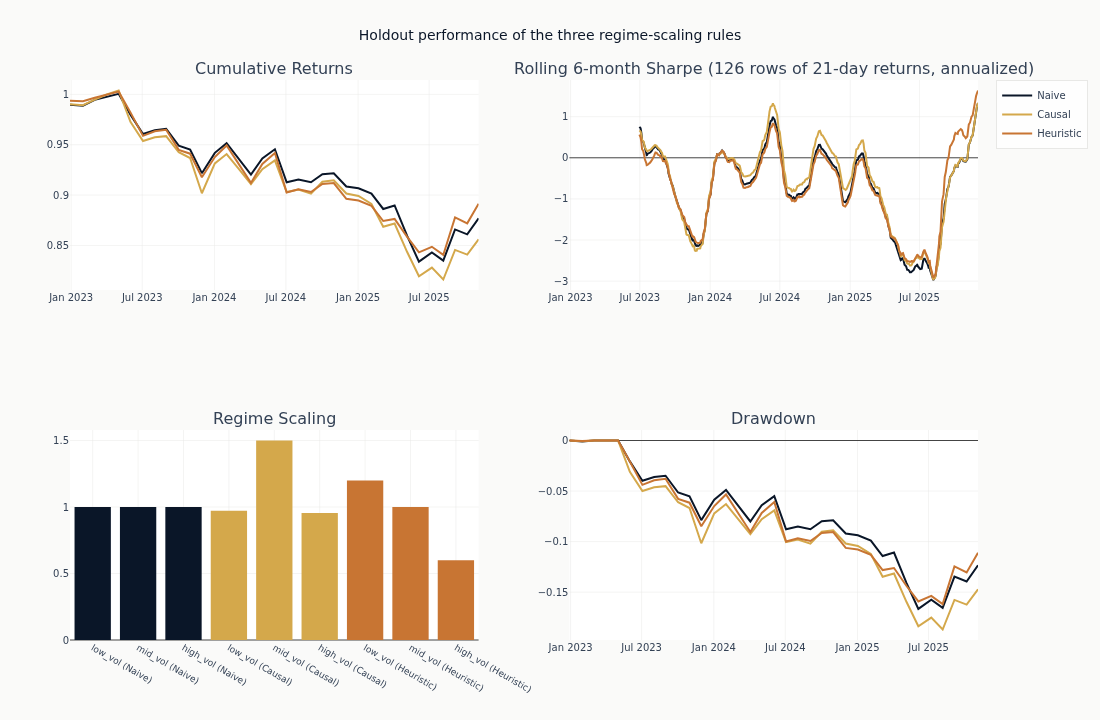

In [27]:
for col, label in [("naive", "Naive"), ("causal", "Causal"), ("heuristic", "Heuristic")]:
    cum = (1 + non_overlap[col]).cumprod()
    fig.add_trace(
        go.Scatter(
            x=non_overlap[date_col],
            y=cum / cum.cummax() - 1,
            name=label,
            line=dict(color=colors[col]),
            showlegend=False,
        ),
        row=2,
        col=2,
    )

fig.update_layout(
    title="Holdout performance of the three regime-scaling rules",
    height=720,
    width=1100,
    barmode="group",
    margin=dict(t=80, b=80, l=70, r=50),
)
# Nine categories at -45 degrees crowd at the default tick size.
fig.update_xaxes(tickfont=dict(size=9), row=2, col=1)
show_plotly_with_alt(
    fig,
    "Four panels comparing the naive, causal and heuristic regime-scaling rules over the "
    "holdout period, one line per rule in three of them. Top left plots cumulative net "
    "return from the non-overlapping series; top right plots a rolling six-month Sharpe "
    "ratio; bottom left is a grouped bar chart of the scaling factor each rule applies in "
    "the low, mid and high volatility regimes; bottom right plots drawdown from each rule's "
    "running peak. In all three line panels the rules track each other closely, and the "
    "cumulative curves end the holdout below where they started.",
)

## 6. What the Holdout Settles

In [28]:
print("\n" + "=" * 60)
print("TRAIN AGAINST HOLDOUT")
print("=" * 60)

test_sharpes = {r["name"]: r["sharpe"] for r in results}

print(f"\nMomentum IC: {train_ic:.4f} in training, {test_ic:.4f} in the holdout")
print("\nHoldout Sharpe by strategy:")
for name, sharpe in test_sharpes.items():
    print(f"  {name:<12} {sharpe:>6.2f}")


TRAIN AGAINST HOLDOUT

Momentum IC: 0.0336 in training, -0.0144 in the holdout

Holdout Sharpe by strategy:
  Naive         -0.19
  Causal        -0.10
  Heuristic     -0.11


### Reading the comparison

The information coefficient printed above is a property of the signal rather than of any
strategy built on it: the average, over dates, of the rank correlation between momentum
and the forward return within that date's cross-section. A sign change between the
training period and the holdout says the association the three rules all lean on was not
stable, which is the first thing to know about any of them. It does not by itself settle
what a strategy earned - the rules trade quintile spreads with regime-dependent exposure,
and an average that flips sign is consistent with several quintile patterns. The three
Sharpe ratios below say what each rule actually did, and neither they nor the IC are
evidence about the causal estimate that produced the scaling.

What the causal analysis establishes is a statement about confounding in the training
period, conditional on the controls being adequate. It is not a forecast, and the holdout
is not a test of it. A regime-conditional effect can be correctly estimated and still fail
to earn anything, because whether it persists is a separate empirical question that the
estimate makes no claim about.

Three practical consequences:

- **Compare against a baseline that costs nothing.** `SIMPLE_HEURISTIC` uses no causal
  machinery. Any gap between it and the causal rule is what the machinery bought; where
  there is no gap, it bought nothing here.
- **Read the sizing rule's floor and cap.** The scaling is clipped to
  `[MIN_SCALING_FLOOR, MAX_SCALING_CAP]` and shrunk toward neutral by `SHRINKAGE`, so a
  noisy CATE cannot produce a large position. That bounds the damage and it also bounds
  the upside.
- **Vary the cost assumption before believing any of it.** The sensitivity table above
  sweeps the round-trip cost, and a ranking that changes across that sweep is a ranking
  about the cost assumption rather than about the strategies.

In [29]:
print("\nHoldout Sharpe by strategy:")
for r in results:
    print(f"  {r['name']:<12} {r['sharpe']:>6.2f}")


Holdout Sharpe by strategy:
  Naive         -0.19
  Causal        -0.10
  Heuristic     -0.11
